## 3D Feature Extraction: CPU vs GPU

This notebook demonstrates **device-agnostic** morphological and intensity
feature extraction from 3D labeled volumes with `cubic`. The exact same
`regionprops_table` call runs on CPU (scikit-image) or GPU (cuCIM) depending
only on where the input arrays live — no code changes. We extract features on
both devices, verify the results are identical up to floating-point precision,
and compare wall-clock time.

**Dataset**: `cells3d` from scikit-image — a 3D fluorescence microscopy volume
(60 × 256 × 256, ZYX) with membrane and nuclei channels; voxel size
(0.29, 0.26, 0.26) µm.

**References**:
- Kalinin et al. (2025) "cubic: CUDA-accelerated 3D BioImage Computing", ICCV Workshop.

In [1]:
import warnings
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt
from skimage.data import cells3d

from cubic.cuda import CUDAManager, asnumpy, to_device
from cubic.skimage import filters, measure, morphology
from cubic.image_utils import label

# Silence scikit-image parameter-deprecation FutureWarnings for a clean tutorial.
warnings.filterwarnings("ignore", category=FutureWarning)

USE_GPU = CUDAManager().num_gpus > 0
print(f"GPU available: {USE_GPU}")

GPU available: True


In [2]:
# cells3d: (60, 2, 256, 256) in ZYX order; channel 1 = nuclei.
# Keep the base arrays on CPU (NumPy); GPU copies are made later so both
# feature-extraction paths see byte-identical inputs.
nuclei = cells3d()[:, 1].astype(np.float32)
SPACING = (0.29, 0.26, 0.26)  # micrometers (Z, Y, X)
XZ_ASPECT = SPACING[0] / SPACING[2]  # physical aspect for XZ views
print(f"Volume shape: {nuclei.shape} (Z, Y, X)")

Volume shape: (60, 256, 256) (Z, Y, X)


### Input volume

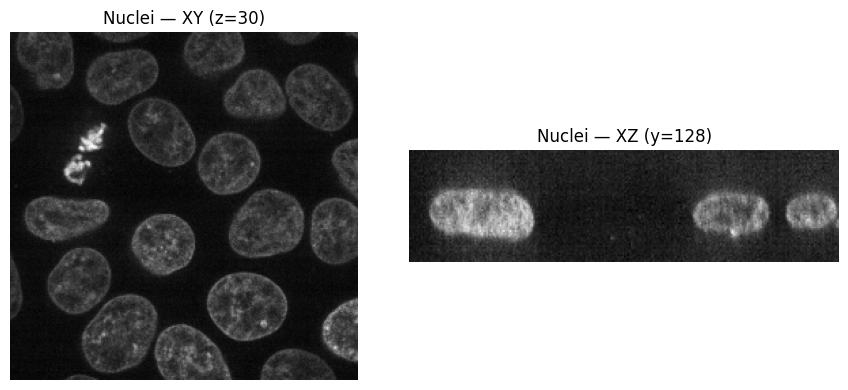

In [3]:
z_mid, y_mid = nuclei.shape[0] // 2, nuclei.shape[1] // 2

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(nuclei[z_mid], cmap="gray")
axes[0].set_title(f"Nuclei — XY (z={z_mid})")
axes[1].imshow(nuclei[:, y_mid, :], cmap="gray", aspect=XZ_ASPECT)
axes[1].set_title(f"Nuclei — XZ (y={y_mid})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Segment nuclei

A simple threshold + cleanup pipeline creates a label image. These operations
are themselves device-agnostic; we run them on CPU here so both the CPU and GPU
feature-extraction paths receive identical labels.

In [4]:
thresh = filters.threshold_otsu(nuclei)
binary = morphology.remove_small_holes(nuclei > thresh, area_threshold=500)
labels = label(binary)
labels = morphology.remove_small_objects(labels, min_size=1000)
labels = label(labels).astype(np.int32)  # relabel sequentially
n_objects = int(labels.max())
print(f"Found {n_objects} nuclei")

Found 18 nuclei


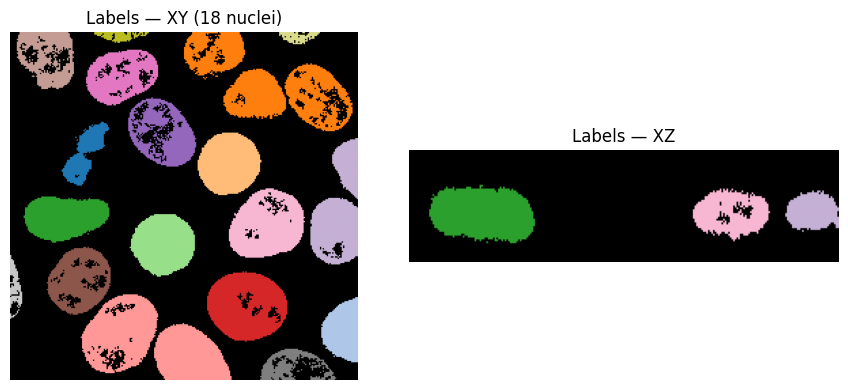

In [5]:
def label_overlay(label_slice):
    """RGB overlay of a label slice: distinct color per label, black background."""
    cmap = plt.get_cmap("tab20")
    lbl = asnumpy(label_slice)
    rgb = np.zeros(lbl.shape + (3,))
    for v in np.unique(lbl):
        if v:
            rgb[lbl == v] = cmap(((v - 1) % 20 + 0.5) / 20)[:3]
    return rgb


fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(label_overlay(labels[z_mid]))
axes[0].set_title(f"Labels — XY ({n_objects} nuclei)")
axes[1].imshow(label_overlay(labels[:, y_mid, :]), aspect=XZ_ASPECT)
axes[1].set_title("Labels — XZ")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Extract features on CPU and GPU

The same `regionprops_table` call runs on both devices — only the input array's
location changes. We extract a set of scalar 3D morphometric and intensity
properties.

Two properties are intentionally excluded so the two backends return the same
columns and values:
- raw image moments (`moments*`): scikit-image emits them to order 3, cuCIM to
  order 2, so the column counts differ;
- `feret_diameter_max`: cuCIM uses an approximate algorithm that can differ from
  scikit-image by a few percent.

In [6]:
PROPS_3D = (
    "label",
    "area",
    "area_bbox",
    "area_convex",
    "area_filled",
    "axis_major_length",
    "axis_minor_length",
    "equivalent_diameter_area",
    "euler_number",
    "extent",
    "solidity",
    "inertia_tensor_eigvals",
    "intensity_max",
    "intensity_mean",
    "intensity_min",
    "intensity_std",
)


def extract(label_image, intensity_image):
    """Time a single regionprops_table call; return (features_dict, seconds)."""
    t0 = perf_counter()
    props = measure.regionprops_table(
        label_image, intensity_image=intensity_image, properties=PROPS_3D
    )
    props = {k: asnumpy(v) for k, v in props.items()}  # dict of NumPy arrays
    return props, perf_counter() - t0


def best_time(label_image, intensity_image, repeats=3):
    """Best-of-N wall time. The first call warms up GPU kernel compilation."""
    extract(label_image, intensity_image)  # warmup
    props, best = None, float("inf")
    for _ in range(repeats):
        props, dt = extract(label_image, intensity_image)
        best = min(best, dt)
    return props, best


# CPU: standard scikit-image on NumPy arrays
props_cpu, t_cpu = best_time(labels, nuclei)
print(
    f"CPU (scikit-image): {t_cpu:.3f}s  |  {len(props_cpu)} feature columns, {n_objects} objects"
)

# GPU: the identical call on CuPy arrays (cuCIM), if a GPU is available
if USE_GPU:
    labels_gpu = to_device(labels, "GPU")
    nuclei_gpu = to_device(nuclei, "GPU")
    props_gpu, t_gpu = best_time(labels_gpu, nuclei_gpu)
    print(f"GPU (cuCIM):        {t_gpu:.3f}s  |  speedup {t_cpu / t_gpu:.1f}x")
else:
    props_gpu, t_gpu = None, None
    print("GPU not available — showing CPU results only")

CPU (scikit-image): 3.945s  |  18 feature columns, 18 objects
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


Found 3 regions with <=1 background pixel spacing from another region. Using slower robust perimeter/euler measurements for these regions.


Found 3 regions with <=1 background pixel spacing from another region. Using slower robust perimeter/euler measurements for these regions.


Found 3 regions with <=1 background pixel spacing from another region. Using slower robust perimeter/euler measurements for these regions.


Found 3 regions with <=1 background pixel spacing from another region. Using slower robust perimeter/euler measurements for these regions.


GPU (cuCIM):        0.506s  |  speedup 7.8x


### Verify CPU and GPU results match

In [7]:
if props_gpu is not None:
    max_abs, worst = 0.0, ""
    for key in props_cpu:
        a = np.asarray(props_cpu[key], dtype=float)
        g = np.asarray(props_gpu[key], dtype=float)
        diff = float(np.nanmax(np.abs(a - g))) if a.size else 0.0
        if diff > max_abs:
            max_abs, worst = diff, key
    same_cols = set(props_cpu) == set(props_gpu)
    print(f"Same columns on both devices: {same_cols} ({len(props_cpu)} columns)")
    print(f"Max absolute difference across all features: {max_abs:.2e} (in '{worst}')")
    print("CPU and GPU feature values are identical up to floating-point precision.")
else:
    print("GPU not available — parity check skipped.")

Same columns on both devices: True (18 columns)
Max absolute difference across all features: 1.72e-03 (in 'intensity_mean')
CPU and GPU feature values are identical up to floating-point precision.


### Feature table

In [8]:
# Key morphological and intensity features (CPU results; GPU values are identical)
key_cols = [
    "label",
    "area",
    "area_convex",
    "solidity",
    "axis_major_length",
    "axis_minor_length",
    "equivalent_diameter_area",
    "intensity_mean",
    "intensity_std",
    "intensity_min",
    "intensity_max",
]
header = " ".join(f"{c:>16s}" for c in key_cols)
print(header)
print("-" * len(header))
for i in range(n_objects):
    row = " ".join(
        f"{float(props_cpu[c][i]):>16.2f}"
        if np.issubdtype(type(props_cpu[c][i]), np.floating)
        else f"{int(props_cpu[c][i]):>16d}"
        for c in key_cols
    )
    print(row)

           label             area      area_convex         solidity axis_major_length axis_minor_length equivalent_diameter_area   intensity_mean    intensity_std    intensity_min    intensity_max
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
               1         29333.00         49895.00             0.59            58.52            25.40            38.26         24355.09         11726.17          7635.00         65535.00
               2         20513.00         24488.00             0.84            48.13            29.38            33.96         19990.91          6358.54          8251.00         65298.00
               3         92047.00        182115.00             0.51           156.15            32.13            56.02         13622.58          2563.43          5880.00         36134.00
               4         36236.00         442

### Feature distributions

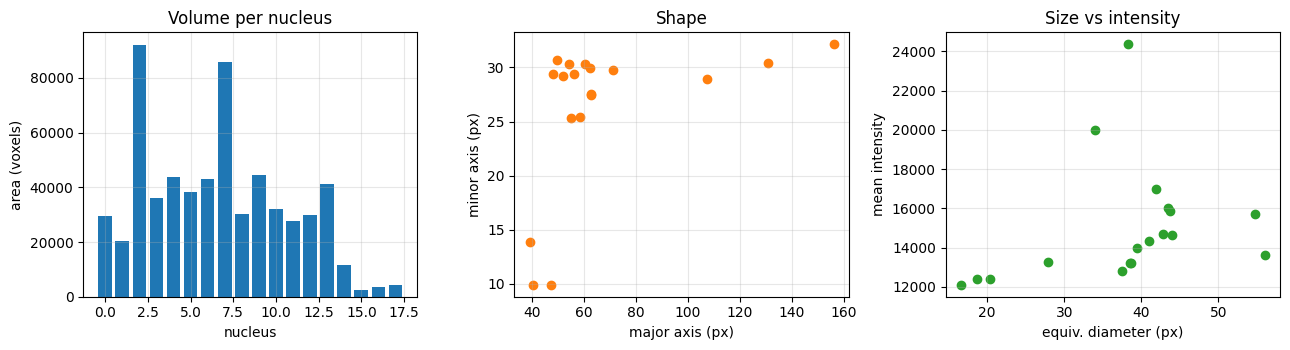

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].bar(range(n_objects), props_cpu["area"], color="C0")
axes[0].set(title="Volume per nucleus", xlabel="nucleus", ylabel="area (voxels)")
axes[1].scatter(props_cpu["axis_major_length"], props_cpu["axis_minor_length"], c="C1")
axes[1].set(title="Shape", xlabel="major axis (px)", ylabel="minor axis (px)")
axes[2].scatter(
    props_cpu["equivalent_diameter_area"], props_cpu["intensity_mean"], c="C2"
)
axes[2].set(
    title="Size vs intensity", xlabel="equiv. diameter (px)", ylabel="mean intensity"
)
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

`cubic` extracts the identical feature matrix on CPU and GPU from a single
`regionprops_table` call — only the input array's device changes. Across all 16
morphometric and intensity properties, CPU (scikit-image) and GPU (cuCIM) values
agree to floating-point precision (max absolute difference printed above).

On an NVIDIA A40, GPU feature extraction runs roughly **8× faster** than CPU
for this 18-nucleus volume (~0.5 s vs ~4 s).

Notes:
- Raw image moments (`moments*`) are omitted because scikit-image emits them to
  order 3 and cuCIM to order 2, so the backends return different column counts.
- `feret_diameter_max` is omitted because cuCIM computes it with an approximate
  algorithm that can differ from scikit-image by a few percent.